# 03 — Visualizations
Loads the cleaned data from `02_data_clean_visualize_me_search.ipynb` and produces all maps.

In [4]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from pathlib import Path


# Find the repo root by searching upward for README.md
# This works no matter where Jupyter is launched from
def find_repo_root(start=Path().resolve()):
    for parent in [start] + list(start.parents):
        if (parent / "README.md").exists() and (parent / "data").exists():
            return parent
    raise FileNotFoundError("Could not find repo root — make sure README.md and data/ exist.")

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

print("Working directory:", os.getcwd())
print("Files in data/:", os.listdir('data'))

Working directory: /Users/charlottewest/Documents/QSS20-CW-Final
Files in data/: ['cleaned_data', 'final_clean_race.csv', '.DS_Store', 'final_map.csv', '01_pulls', 'raw', 'nj_pfas_map.png']


## Load cleaned data

In [ ]:
# Load shapefile and cleaned data, then merge
# Drop the text geometry column from the CSV — the real geometry comes from the GeoJSON
nj_shapes = gpd.read_file('data/01_pulls/nj_zcta_2024.geojson')
final_df  = pd.read_csv('data/cleaned_data/final_map.csv', dtype={'ZIPCODE': str})
final_df  = final_df.drop(columns=[c for c in final_df.columns if 'geometry' in c.lower()])

map_df = nj_shapes.merge(final_df, on='ZIPCODE', how='left')
map_df = map_df.set_geometry('geometry')

print(map_df.columns.tolist())

## Mean PFAS concentration by ZIP (ng/L)

AttributeError: The CRS attribute of a GeoDataFrame without an active geometry column is not defined. Use GeoDataFrame.set_geometry to set the active geometry column.

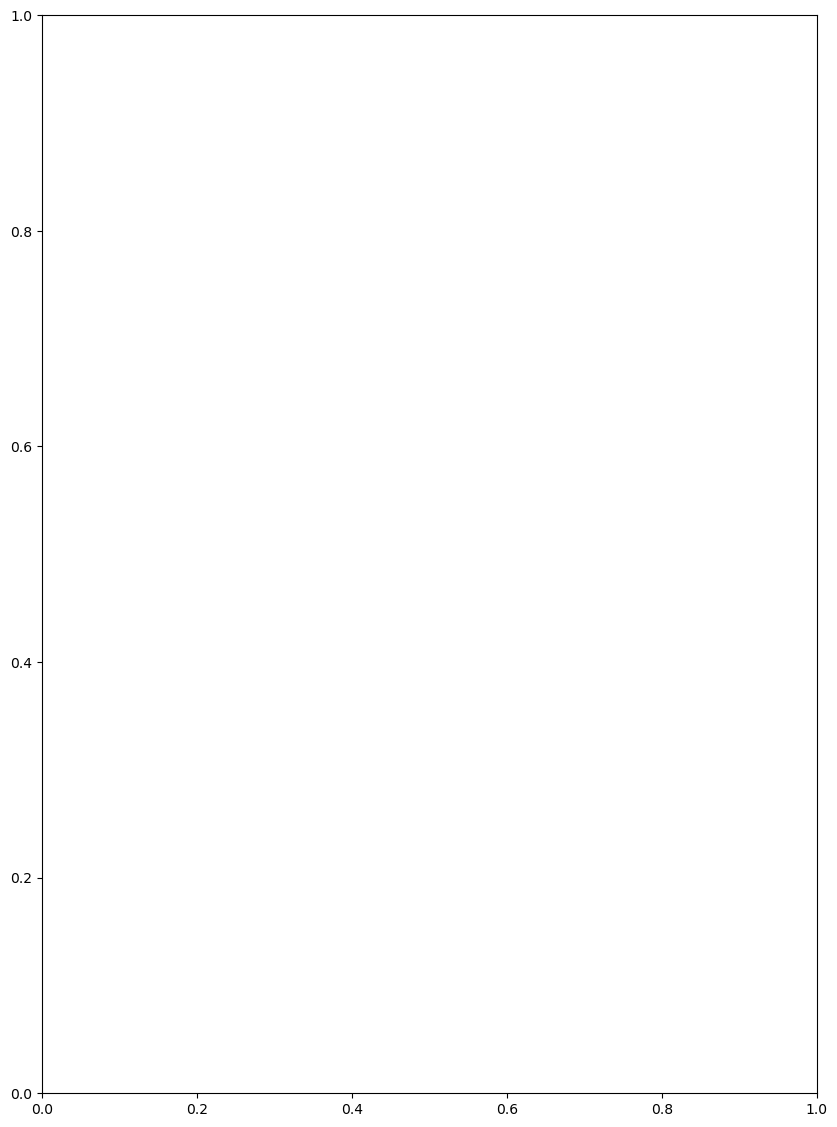

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

map_df.plot(
    column       = 'mean_pfas',
    cmap         = 'OrRd',
    linewidth    = 0.5,
    edgecolor    = 'black',
    legend       = True,
    missing_kwds = {'color': 'lightgrey', 'label': 'No Data'},
    ax           = ax
)

ax.set_title('Mean PFAS Levels by ZIP Code in New Jersey (ng/L)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('output/nj_pfas_map_mean.png', dpi=300, bbox_inches='tight')
plt.show()

## Mean PFAS concentration by ZIP (ng/L)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

map_df.plot(
    column       = 'mean_pfas_ngl',
    cmap         = 'OrRd',
    linewidth    = 0.5,
    edgecolor    = 'black',
    legend       = True,
    missing_kwds = {'color': 'lightgrey', 'label': 'No Data'},
    ax           = ax
)

ax.set_title('Mean PFAS Levels by ZIP Code in New Jersey (ng/L)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('output/nj_pfas_map_mean.png', dpi=300, bbox_inches='tight')
plt.show()

## Binary map — ZIP codes exceeding EPA MCL (4 ng/L)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 14))

cmap_binary = ListedColormap(['#d3d3d3', '#d73027'])

map_df.plot(
    column       = 'max_exceeds_EPA',
    cmap         = cmap_binary,
    linewidth    = 0.5,
    edgecolor    = 'black',
    legend       = False,
    missing_kwds = {'color': 'lightgrey'},
    ax           = ax
)

legend_elements = [
    Patch(facecolor='#d73027', edgecolor='black', label='Exceeds EPA MCL (> 4 ng/L)'),
    Patch(facecolor='#d3d3d3', edgecolor='black', label='Below EPA MCL'),
    Patch(facecolor='lightgrey', edgecolor='black', label='No Data'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=11)

ax.set_title('ZIP Codes Exceeding EPA PFAS Limit (4 ng/L) in New Jersey',
             fontsize=15, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('output/nj_pfas_exceeds_mcl.png', dpi=300, bbox_inches='tight')
plt.show()

## PFAS contamination vs race (side by side)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 14))

# Left — mean PFAS
map_df.plot(
    column       = 'mean_pfas_ngl',
    cmap         = 'OrRd',
    linewidth    = 0.5,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey'},
    ax           = axes[0]
)
legend = axes[0].get_legend()
if legend is not None:
    legend.set_title('PFAS (ng/L)', prop={'size': 10})
axes[0].set_title('Mean PFAS Concentration by ZIP (ng/L)', fontsize=14, fontweight='bold')
axes[0].set_axis_off()

# Right — % minority
map_df.plot(
    column       = 'pct_minority',
    cmap         = 'Blues',
    linewidth    = 0.5,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey'},
    ax           = axes[1]
)
legend = axes[1].get_legend()
if legend is not None:
    legend.set_title('% Minority', prop={'size': 10})
axes[1].set_title('% Minority Population by ZIP', fontsize=14, fontweight='bold')
axes[1].set_axis_off()

plt.suptitle('PFAS Contamination vs Race in New Jersey',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/nj_pfas_vs_race_map.png', dpi=300, bbox_inches='tight')
plt.show()